In [73]:
from typing import TypedDict, List, Annotated, Optional
from langgraph.graph import StateGraph, START, END, add_messages, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from tavily import TavilyClient
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, SystemMessage
from huggingface_hub import InferenceClient
from exa_py import Exa
from langgraph.types import Send
import os
import json
from operator import add
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from IPython.display import Image, display
from db.database import SessionLocal, init_db
from db.crud import create_track, save_syllabus
import re
load_dotenv()
init_db()


In [76]:
llm=ChatGroq(model_name="llama-3.1-8b-instant", api_key=os.getenv('GROQ_API'))


In [77]:
llm.invoke("what is your name").content

'I\'m an artificial intelligence model known as Llama. Llama stands for "Large Language Model Meta AI."'

In [21]:
tavily_client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))
response = tavily_client.search("tell me about mutual funds", include_answer=True)
response['answer']


'A mutual fund pools money from many investors to buy securities like stocks and bonds. It allows individuals to invest collectively and diversify their portfolios. Mutual funds are managed by professionals to maximize returns.'

In [22]:
exa = Exa(api_key=os.getenv("EXA_API_KEY"))

result = exa.search(
  "blog post about artificial intelligence",
  type="auto",
  contents={
    "highlights": {
      "max_characters": 4000
    }
  }
)

In [23]:
print(result)

Title: Artificial Intelligence Blog: AI Blog
URL: https://www.artificial-intelligence.blog/
ID: https://www.artificial-intelligence.blog/
Score: None
Published Date: None
Author: None
Image: http://static1.squarespace.com/static/62ec2bc76a27db7b37a2b32f/t/68974039b71d0f1a6f3e6920/1754742841664/of+ai-blog-youtube-2025.png?format=1500w
Favicon: https://images.squarespace-cdn.com/content/v1/62ec2bc76a27db7b37a2b32f/abfb4587-35b3-411f-8603-7e24344b95fc/favicon.ico?format=100w
Extras: None
Subpages: None
Text: None
Summary: None
Highlights: [' this website as a form of digital art, as all images and text were generated by artificial intelligence(with a little bit of human help). ## AI Blog Posts & AI News\n\n3 Actionable AI Recommendations for Businesses in 2026 education, business, technology In 2026, AI advantage will not come from tools but from focus. This piece outlines three concrete, disruptive moves businesses can make to turn AI into durable leverage, plus the contrarian and pessim

In [24]:
class SyllabusItem(BaseModel):
    day: int = Field(description="Day number in the syllabus")
    title: str = Field(description="Title for the day")
    concepts: List[str] = Field(
        description="2 to 4 concepts introduced on this day"
    )
class AgentState(TypedDict):
    topic: str
    total_days: int
    syllabus: list[SyllabusItem]  # [{day, title, goal, concepts}]
    revision_count: int = 0     # tracks retry loops
    quality_score: float = 0.0,
    track_id: int

class SyllabusOutput(BaseModel):
    syllabus: List[SyllabusItem]
    
class DaysDecision(BaseModel):
    total_days: int = Field(ge=3, le=14, description="Number of days needed to cover this topic well for a beginner")
    reasoning:  str = Field(description="One sentence explaining why this many days")


In [25]:

def parse_input(state: AgentState) -> dict:
    """
    Sanitise topic, then let the LLM decide the optimal number of days
    based on the topic's breadth and complexity.
    Falls back to user-provided total_days if LLM call fails.
    """
    cleaned_topic = state['topic'].strip()
    
    llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))
    structured_llm = llm.with_structured_output(DaysDecision)

    try:
        decision: DaysDecision = structured_llm.invoke([
            SystemMessage(content="""You are a curriculum planner for a beginner learning newsletter.
Your job is to decide how many days a topic needs to be covered well — 
not too shallow, not overwhelming.

Guidelines:
- 3 days:  very focused, narrow topic (e.g. "what is a token", "how GPS works")
- 5 days:  clear single-domain topic (e.g. "how transformers work", "what is inflation")
- 7 days:  broader topic with multiple interconnected ideas (e.g. "how the internet works", "what is machine learning")
- 10 days: wide domain needing real depth (e.g. "the history of AI", "how financial markets work")
- 14 days: only for very broad domains a beginner needs significant time to absorb (e.g. "quantum computing", "evolutionary biology")

Always prefer fewer days. A tight 5-day arc beats a padded 10-day one."""),
            HumanMessage(content=f"""
Topic: "{cleaned_topic}"

How many days does this topic need for a complete beginner to genuinely understand it?
Stay between 3 and 14 days.
""")
        ])

        total_days = decision.total_days
        print(f"[parse_input] topic='{cleaned_topic}' → {total_days} days ({decision.reasoning})")

    except Exception as e:
        # Fall back to user-provided value, clamped to safe range
        total_days = max(3, min(14, state.get('total_days', 5)))
        print(f"[parse_input] LLM decision failed ({e}) — using {total_days} days")

    return {
        "topic":      cleaned_topic,
        "total_days": total_days,
    }

In [26]:
def generate_syllabus(state: AgentState) -> dict:
    structured_llm = llm.with_structured_output(SyllabusOutput)
    response: SyllabusOutput = structured_llm.invoke([
        SystemMessage(content="""You are an expert curriculum designer 
        specialising in beginner-friendly conceptual learning paths.
        You MUST return the response using the provided tool schema.
        The output must contain a field called `syllabus`.
        
        Your curriculum is purely theoretical — no setup, no coding, no tools.
        Every concept should be something the reader understands deeply,
        not something they do or install."""),
        HumanMessage(content=f"""
Design a {state['total_days']}-day conceptual learning curriculum for: "{state['topic']}"
Target level: complete beginner — no prior knowledge assumed

Rules:
1. Day 1 must explain what {state['topic']} is, where it came from, and why it matters
2. Each day must introduce exactly 3–4 concepts
3. Concepts must be ideas, mental models, or principles — never tasks or actions
4. Concepts must build logically from previous days
5. Day {state['total_days']} must synthesise everything — how the concepts connect and what the bigger picture looks like
6. Titles should spark curiosity, not sound like a course syllabus
7. Never include: installation, setup, coding, tools, frameworks, or hands-on tasks
""")
    ])

    print(f"[generate_syllabus] Generated {len(response.syllabus)} days")
    return {"syllabus": [s.model_dump() for s in response.syllabus]}

In [27]:
def save_to_db(state: AgentState) -> dict:
    """
    Creates a Track row and saves all SyllabusItems to SQLite.
    Returns track_id so downstream systems (Graph 2) can reference it.
    """
    db = SessionLocal()
    try:
        # Create the track
        track = create_track(
            db=db,
            topic=state["topic"],
            total_days=state["total_days"],
        )

        # Save every syllabus item
        save_syllabus(
            db=db,
            track_id=track.id,
            syllabus=state["syllabus"],   # already list[dict] from model_dump()
        )

        print(f"[save_to_db] Track {track.id} saved — {len(state['syllabus'])} days")
        return {"track_id": track.id}

    except Exception as e:
        db.rollback()
        print(f"[save_to_db] Failed: {e}")
        raise
    finally:
        db.close()

In [28]:
def build_curriculum_graph():
    g = StateGraph(AgentState)

    # nodes
    g.add_node("parse_input",       parse_input)
    g.add_node("generate_syllabus", generate_syllabus)
    g.add_node("save_to_db", save_to_db)

    # edges (connections)
    g.add_edge(START, "parse_input")
    g.add_edge("parse_input", "generate_syllabus")
    g.add_edge("generate_syllabus","save_to_db")
    g.add_edge("save_to_db",END)

    # Optionally, return or use the graph
    return g.compile()


In [29]:
curriculum_graph = build_curriculum_graph()

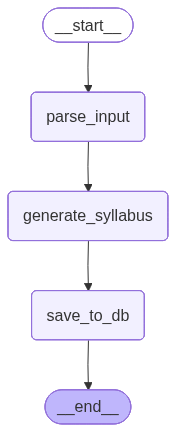

In [30]:
display(Image(curriculum_graph.get_graph().draw_mermaid_png()))

In [31]:
test_state = {
    "topic": "Machine Learning",
    "total_days": 1,
    "syllabus": []}

result = curriculum_graph.invoke(test_state)
print(result)

[parse_input] topic='Machine Learning' → 7 days (Machine learning is a broader topic with multiple interconnected ideas, such as supervised and unsupervised learning, neural networks, and deep learning, which can be covered in 7 days.)


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01j8g1njfaft9bwzpgra60m4xh` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99649, Requested 524. Please try again in 2m29.472s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

MAKING THE SECOND GRAPH

In [228]:
exa = Exa(api_key=os.getenv("EXA_API_KEY"))

result = exa.search(
  "Unlocking the Power of Claude 4.6: What's the Big Deal?",
  type="auto",
  num_results=10,
  contents={
    "highlights": {
      "max_characters": 4000
    }
  }
)

In [229]:
result

SearchResponse(results=[Result(url='https://www.anthropic.com/news/claude-opus-4-6', id='https://www.anthropic.com/news/claude-opus-4-6', title='Introducing Claude Opus 4.6', score=None, published_date=None, author=None, image='https://cdn.sanity.io/images/4zrzovbb/website/01d06528567e4bd22c3ddedc87f609ee5716a009-2400x1260.png', favicon='https://www.anthropic.com/favicon.ico', subpages=None, extras=None, entities=None, text=None, summary=None, highlights=[" It plans more carefully, sustains agentic tasks for longer, can operate more reliably in larger codebases, and has better code review and debugging skills to catch its own mistakes. And, in a first for our Opus-class models, Opus 4.6 features a 1M token context window in beta1. Opus 4.6 can also apply its improved abilities to a range of everyday work tasks: running financial analyses, doing  ...    can multitask autonomously, Opus 4.6 can put all these skills to work on your behalf. The model’s performance is state-of-the-art on se

In [129]:
from typing import List
from pydantic import BaseModel


class SyllabusItem(BaseModel):
    day: int
    title: str
    concepts: List[str]


class ExaResult(BaseModel):
    url: str
    title: str
    snippet: str


class Section(BaseModel):
    concept: str
    heading: str
    key_points: List[str]
    exa_queries: List[str]        # max 2, Exa fires these


class Plan(BaseModel):
    newsletter_title: str
    hook: str
    tone: str
    sections: List[Section]
    takeaway: str

class ResearchSummary(BaseModel):
    concept: str
    summary: str   
    key_points: list[str]
    top_links: List[str] 
    
class ContentState(BaseModel):
    item: SyllabusItem
    plan: Plan | None = None
    research: List[ExaResult] = []
    research_summary: List[ResearchSummary] = []
    draft: str = ""
    feedback: str = ""
    revision_count: int = 0
    approved: bool = False
    newsletter: str = ""

In [136]:
def planner_node(state: ContentState) -> dict:
    PLANNER_PROMPT = """
You are creating the outline for a modern tech newsletter lesson.

The writing style should feel like popular tech newsletters such as TLDR, The Neuron, or AI Brew: smart, conversational, and easy to skim.

The reader should feel like they learned something useful in under 60 seconds.

Your job is NOT to write the full article. Your job is to produce a structured PLAN that a writer will expand into the final newsletter section.

--------------------------------------------------

INPUTS

Day: {day}
Topic Title: {title}
Concepts: {concepts}

--------------------------------------------------

TASK

Create a structured plan for a newsletter lesson.

--------------------------------------------------

INSTRUCTIONS

1. NEWSLETTER TITLE

Write a catchy newsletter-style title.

The title should:
- spark curiosity
- feel modern
- avoid textbook wording

Examples:
"Neural Networks: The Brains Behind Modern AI"
"The 3 Building Blocks Powering Every AI System"

--------------------------------------------------

2. HOOK (2–3 sentences)

Write a short opening hook that grabs attention.

The hook should:
- introduce the topic quickly
- create curiosity
- explain why the reader should care

Example tone:

"Every AI system you hear about — from ChatGPT to self-driving cars — runs on the same core idea: neural networks.

But the strange part? These powerful systems are built from extremely simple mathematical units.

Today we'll break down the three building blocks that make it all work."

--------------------------------------------------

3. SECTIONS

For EACH concept create a section containing:

heading  
A fun, engaging section title.

Avoid generic titles like:
"Introduction to..."

Examples:
"Meet the Tiny Neurons Running the Show"
"Stacking Layers to Build Intelligence"

key_points

Write 3–5 bullet ideas explaining HOW the concept works.

Rules:
- explain the mechanism
- avoid vague statements
- focus on intuition
- keep sentences short

Bad example:
"Neurons process data"

Good example:
"A neuron takes numbers as input and multiplies them by learned weights."

analogy

Provide a simple real-world analogy that helps beginners understand the concept.

Examples:
- neurons = voting system
- layers = factory assembly line
- activation functions = decision switch

exa_queries

Provide up to 2 search queries that would help find:
- examples
- case studies
- explanations

Queries should be specific and useful.

--------------------------------------------------

4. STYLE GUIDELINES

The final article should feel:

• clear  
• engaging  
• beginner friendly  
• easy to skim  

Use:
- short sentences
- concrete explanations
- intuitive mental models

Avoid:
- academic language
- textbook definitions
- vague bullet points

--------------------------------------------------

5. TAKEAWAY

End with one memorable sentence capturing the big idea.

Example:

"Big idea: neural networks turn simple math operations into powerful pattern-recognition machines."

--------------------------------------------------

OUTPUT REQUIREMENTS

Return ONLY valid JSON matching the Plan schema.

Important rules:

- "sections" MUST be a JSON array
- Do NOT wrap arrays or objects as strings
- Do NOT include markdown
- Do NOT include explanations
- Do NOT include text outside the JSON"""

    prompt = PLANNER_PROMPT.format(
        day=state.item.day,
        title=state.item.title,
        concepts=", ".join(state.item.concepts),
    )
    llm=ChatGroq(model_name="llama-3.1-8b-instant", api_key=os.getenv('GROQ_API_KEY'))
    plan = llm.with_structured_output(Plan).invoke(prompt)

    return {"plan": plan}

In [137]:
def research_node(state: ContentState) -> dict:
    """Based on the exa queries defined in the planner node, the exa search will be triggered"""
    
    exa_queries_list = []
    for section in state.plan.sections:
        for query in section.exa_queries:
            exa_queries_list.append(query)
    
    print(f"\n{'='*60}")
    print(f"🔍 RESEARCHER NODE")
    print(f"{'='*60}")
    print(f"📋 Total queries to run: {len(exa_queries_list)}")
    for i, q in enumerate(exa_queries_list, 1):
        print(f"   {i}. {q}")

    query_results = []
    seen_urls = set()
    for query in exa_queries_list:
        print(f"\n🔎 Searching: '{query}'")
        result = exa.search(
            query,
            type="neural",
            num_results=3,
            contents={
                "highlights": {
                    "max_characters": 4000
                },"text":True, 'summary': True
            },
            include_domains=[
            "developers.google.com",
            "coursera.org", 
            "arxiv.org",
            "datacamp.com",
            "baeldung.com",
            "wikipedia.org",
            "towardsdatascience.com"
        ]
        )
        for item in result.results:
            if item.url in seen_urls:
                continue

            seen_urls.add(item.url)
            exa_result = ExaResult(
                url=item.url,
                title=item.title,
                snippet=item.summary
            )
            query_results.append(exa_result)
            print(f"   ✅ {item.title}")
            print(f"      🔗 {item.url}")
            print(f"      📝 {exa_result.snippet[:100]}...")

    print(f"\n{'='*60}")
    print(f"✅ Research complete — {len(query_results)} results collected")
    print(f"{'='*60}\n")

    return {"research": query_results}

In [144]:
def summariser_node(state: ContentState)->ContentState:
    """summarise the reseach done by exa"""
    SUMMARIZER_PROMPT = """
You are helping create a beginner-friendly learning newsletter.

Concept: {concept}

Below are research results collected from the internet.

{raw_results}

Your task:

1. Extract the most useful information for someone learning this topic.
2. Ignore navigation text, ads, sign-in prompts, and irrelevant junk.
3. Focus on explanations, definitions, and simple examples.

Output requirements:

Write:
- summary → a 4-5 sentence explanation of the concept
- key_points → 3 short learning bullet points
- top_links → 2-3 beginner friendly URLs

NOTE: 
-Avoid repeating ideas across bullet points.
-Each key point must describe a different concept.

Return a valid ResearchSummary object.
"""
    print(f"\n{'='*60}")
    print("📝 SUMMARIZER NODE")
    print(f"{'='*60}")
    print(f"📋 Total research results: {len(state.research)}")

    summaries = []

    # Create concept → results mapping
    concept_results_map = {
        section.concept: [] for section in state.plan.sections
    }

    # Group research results by concept
    for result in state.research:
        for section in state.plan.sections:
            concept = section.concept.lower()

            if concept in result.title.lower() or concept in result.snippet.lower():
                concept_results_map[section.concept].append(result)

    # Summarize each concept
    for concept, concept_results in concept_results_map.items():

        if not concept_results:
            print(f"\n⚠️ No research found for concept: {concept}")
            continue

        print(f"\n🔎 Summarizing concept: {concept}")
        print(f"📦 Raw sources found: {len(concept_results)}")

        # limit sources for better LLM performance
        concept_results = concept_results[:5]

        # Format results for LLM
        raw_results = "\n\n".join([
            f"""
SOURCE {i+1}
Title: {r.title}
URL: {r.url}
Snippet: {r.snippet}
"""
            for i, r in enumerate(concept_results)
        ])

        prompt = SUMMARIZER_PROMPT.format(
            concept=concept,
            raw_results=raw_results
        )
        llm=ChatGroq(model="llama-3.1-8b-instant", api_key=os.getenv("GROQ_API_KEY"))
        summary = llm.with_structured_output(ResearchSummary).invoke(prompt)

        summaries.append(summary)

        print("   ✅ Summary generated")
        print(f"   📎 Links kept: {summary.top_links}")

    print(f"\n{'='*60}")
    print(f"✅ Summarization complete — {len(summaries)} summaries ready")
    print(f"{'='*60}\n")

    return {"research_summary": summaries}
    
    

In [139]:
from langgraph.graph import StateGraph, START, END


def build_graph():
    g = StateGraph(ContentState)

    # Add node
    g.add_node("planner_node", planner_node)
    g.add_node("research_node", research_node)
    g.add_node("summariser_node", summariser_node)

    # Connect start → node
    g.add_edge(START, "planner_node")
    g.add_edge("planner_node",'research_node')
    g.add_edge("research_node",'summariser_node')

    # Connect node → end
    g.add_edge("summariser_node", END)

    return g.compile()

In [140]:
graph = build_graph()

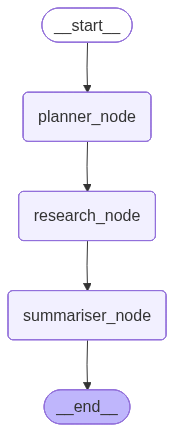

In [141]:
graph

In [ ]:
esult = graph.invoke({
    "item": {
        "day": 1,
        "title": "Introduction to Neural Networks",
        "concepts": [
            "neurons",
            "layers",
            "activation functions"
        ]
    }
})



🔍 RESEARCHER NODE
📋 Total queries to run: 6
   1. what are examples of neurons in action
   2. how do neurons work in neural networks
   3. how do layers work in convolutional neural networks
   4. what are examples of deep layers in neural networks
   5. what are examples of activation functions
   6. how do activation functions work in neural networks

🔎 Searching: 'what are examples of neurons in action'
   ✅ Grid cell
      🔗 https://en.wikipedia.org/wiki/Grid_cell
      📝 The webpage explains how grid cells, a type of neuron in the entorhinal cortex, become active as an ...
   ✅ Action potential
      🔗 https://en.wikipedia.org/wiki/Action_potential
      📝 Examples of neurons in action include transmitting nerve impulses along their axons to communicate w...
   ✅ Single-unit recording
      🔗 https://en.wikipedia.org/wiki/Single-unit_recording
      📝 Single-unit recordings capture the electrical activity of individual neurons, such as action potenti...

🔎 Searching: 'how do neu

KeyError: 'research_summary'

In [143]:
print(esult["research_summary"])

[ResearchSummary(concept='neurons', summary='Neurons are the fundamental units of the brain and nervous system, responsible for transmitting and processing information. They work by generating and propagating electrical signals, known as action potentials, which enable various functions such as sensory perception, muscle movement, and neural communication. Neurons are connected to each other through synapses, allowing them to exchange information and form complex neural networks. In artificial neural networks, neurons are the basic building blocks that mimic biological neurons, processing data and transmitting signals based on thresholds. Understanding neurons is essential for grasping how the brain works and how neural networks can be applied in various fields.', key_points=['Neurons generate and propagate electrical signals, known as action potentials, to communicate with other neurons, muscles, or glands.', 'Artificial neurons mimic biological neurons, processing data and transmitti